# Proyecto 01: Conociendo la Imagen

## 0. Código y Funciones Auxiliares

In [1]:
# Import de librerías para la realización del proyecto

from pathlib import Path
from typing import Callable

import cv2
import numpy as np
import matplotlib.pyplot as plt

### 0.1 Carga y Visualización de Imágenes

In [2]:
def load_images_dataset():
    """
    Función para cargar/leer las imágenes del dataset del proyecto. 
    Se cargan usando OpenCV y convertidas al formato RGB.

    Devuelve dos listas, una con las imágenes cargadas y otra 
    con los nombres de las imágenes.
    """

    base_path = Path("./dataset")
    images = []
    filenames =  []
    for path in base_path.iterdir():
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        images.append(image)
        filenames.append(path.name)
    return images, filenames

In [3]:
map_channels_name = {
    "R": "Rojo",
    "G": "Verde",
    "B": "Azul"
}

def visual_describe_image(image: np.ndarray, filename: str) -> plt.Figure:
    """
    Genera el plot que describe visualmente una imagen al 
    presentarla en el formato RGB (original), a escala de grises 
    y la visualización de los diferentes canales de color (
    descomposición en canales).

    Devuelve el plot diseñado.
    """

    fig, axes = plt.subplot_mosaic(
        ".CCSS.\n"\
        "RRBBGG",
        subplot_kw = {
            "yticks": [],
            "xticks": [],
        },
        figsize = (8, 6),
    )
    fig.suptitle(f"Imagen Original, a Escala de Grises y Canales de la Imagen {filename[-5]}")

    axes["C"].imshow(image)
    axes["C"].set_title("Original")

    axes["S"].imshow(cv2.cvtColor(image, cv2.COLOR_RGB2GRAY), "gray")
    axes["S"].set_title("Escala de grises")

    for channel, (color, name) in enumerate(map_channels_name.items()):
        image_channel = np.zeros_like(image)
        image_channel[:, :, channel] = image[:, :, channel]
        axes[color].imshow(image_channel)
        axes[color].set_title(f"Canal {color} ({name})")

    return fig

def channels_histograms(image: np.ndarray, filename: str) -> plt.Figure:
    """
    Función para generar el plot con los histogramas 
    por cada canal de color de la imagen original. 

    Devuelve el plot diseñado.
    """

    fig, axes = plt.subplots(
        ncols = 3,
        subplot_kw = {
            "xlim": (0, 255),
        },
        figsize = (14, 4),
    )

    fig.suptitle(f"Histograma por Canales de la Imagen {filename[-5]} de Tamaño {image.shape[1]}px por {image.shape[0]}px (Ancho por Alto)")

    for channel, (color, name) in enumerate(map_channels_name.items()):
        intensities = image[:, :, channel].reshape(-1)
        axes[channel].hist(intensities, bins=256, color=color.lower())
        axes[channel].set_title(f"Canal {color} ({name})")

    return fig

In [4]:
images, filenames = load_images_dataset()

### 0.2 Transformaciones para Ajuste de Brillo y Contraste

In [5]:
def image_limits_adjust(
        factor_scaling: float = 1,
    ) -> Callable:
    """
    Función para inicializar el decorador para 
    reajustar el rango de salida después de aplicarle 
    una transformación a una imagen de forma 
    que la intensidad de los colores estén en [0, 255]

    Devuelve el decorador para ajustar el rango de 
    colores de la imagen al aplicar un factor de escala.
    """

    def image_adjust_wrapper(transformation: Callable[[np.ndarray], np.ndarray]) -> Callable:

        def image_adjust(image: np.ndarray, *args, **kwargs) -> np.ndarray:
            transformed_image = transformation(image, *args, **kwargs)
            return (factor_scaling*transformed_image).round().astype(int).clip(0, 255)
        return image_adjust
    
    return image_adjust_wrapper

@image_limits_adjust()
def gain_bias_transformation(
        image: np.ndarray,
        gain_c: float,
        bias_b: float,
        channels: list[int] | None = None,
    ) -> np.ndarray:
    """
    Función para aplicar una ganancia (gain) y 
    un sesgo (bias). Esta función permite 
    ajustar el contraste con gain y el brillo 
    con el bias.
    """

    if not channels:
        transf_image = gain_c*image.astype(int)+bias_b
    else:
        transf_image = image.copy().astype(int)
        transf_image[:, :, channels] = gain_c*image[:, :, channels]+bias_b
    
    return transf_image

def negative_transformation(image: np.ndarray) -> np.ndarray:
    """
    Función para devolver el negativo de una imagen.
    """

    return gain_bias_transformation(image, -1, 255)

@image_limits_adjust()
def gamma_correction(
        image: np.ndarray,
        gamma: float,
        factor_k: float = 1,
        channels: list[int] | None = None,
    ) -> np.ndarray:
    """
    Función para aplicar una corrección 
    gamma. Esta función permite ajustar 
    el contraste y brillo de forma 
    exponencial (no lineal)
    """

    if not channels:
        transf_image = factor_k*image**gamma
    else:
        transf_image = image.copy()
        transf_image[:, :, channels] = factor_k*image[:, :, channels]**gamma
    
    return transf_image

@image_limits_adjust()
def logarithm_transformation(
        image: np.ndarray,
        factor_k: float = None,
    ) -> np.ndarray:
    """
    Función para aplicar una corrección 
    logarítmica. Esta función permite ajustar 
    el contraste y brillo de una imagen 
    de forma logarítmica.
    """

    if not factor_k:
        factor_k = 255/np.log10(1+image.max())
    
    return factor_k*np.log10(1+image)

@image_limits_adjust(factor_scaling=255)
def sigmoid_correction(
        image: np.ndarray,
        threshold: float,
        factor_c: float,
    ) -> np.ndarray:
    """
    Función aplicar una "binarización" a las 
    intensidad de una imagen
    """

    norm_image = normalize_image(image)
    return 1/(1+np.exp(factor_c*(threshold-norm_image)))

@image_limits_adjust(factor_scaling=255)
def histogram_equalize(
        image: np.ndarray,
        channels: list[int] | None = None,
    ) -> np.ndarray:
    """
    Función para aplicar una ecualización de contraste 
    empleando su histograma. Esta función permite ecualizar 
    el rango de contraste en una imagen.
    """

    if len(image.shape) == 2:
        image = np.expand_dims(image, 2)
    
    if not channels:
        equalize_image = np.apply_over_axes(equalize_channel, image, 2)
    else:
        equalize_image = image.copy()
        equalize_image[:, :, channels] = np.apply_over_axes(equalize_channel, image[:, :, channels], 2)

    return equalize_image

def equalize_channel(image_channel: np.ndarray, axis) -> np.ndarray:
    """
    Función para ecualizar un único canal de 
    color empleando su histograma.

    Devuelve un canal ecualizado de la imagen.
    """

    histogram, _ = np.histogram(image_channel, bins=256)
    normalized_histogram = histogram/image_channel.size
    running_sum = normalized_histogram.cumsum()
    return running_sum[image_channel]

def normalize_image(image: np.ndarray) -> np.ndarray:
    """
    Función para normalizar el rango de contraste de una 
    imagen por canal. 

    Devuelve una imagen cuyas intensidades están en [0, 1]
    """

    min_intensities_channel = image.min(axis=(0,1), keepdims=True)
    max_intensities_channel = image.max(axis=(0,1), keepdims=True)

    range_intensities_channel = max_intensities_channel-min_intensities_channel
    norm_image = (image-min_intensities_channel)/range_intensities_channel 
    return norm_image

### 0.3 Comparación de Transformaciones

In [6]:
def gain_bias_comparison(
        image: np.ndarray, 
        filename: str, 
        gain: float, 
        bias: float,
        channels: list[int] | None = None,
    ) -> plt.Figure:
    """
    Función para comparar visualmente los 
    efecto de aplicar un gain y bias.

    Devuelve el plot diseñado.
    """

    fig, axes = plt.subplots(
        ncols = 2,
        subplot_kw = {
            "yticks": [],
            "xticks": [],
        },
        figsize = (10, 4.5),
    )

    fig.suptitle(f"Comparativa de Usar Gain-Bias en la Imagen {filename[-5]}")

    axes[0].imshow(image)
    axes[0].set_title("Imagen original")

    axes[1].imshow(gain_bias_transformation(image, gain, bias, channels))
    axes[1].set_title(f"Imagen Gain-Bias")

    return fig

In [7]:
def gamma_correction_comparison(
        image: np.ndarray, 
        filename: str, 
        lower_gamma: float, 
        higher_gamma: float,
        channels: list[int] | None = None,
    ) -> plt.Figure:
    """
    Función para comparar visualmente los efectos 
    de correcciones gammas con diferentes valores.

    Devuelve el plot diseñado.
    """

    fig, axes = plt.subplots(
        ncols = 3,
        subplot_kw = {
            "yticks": [],
            "xticks": [],
        },
        figsize = (14, 4),
    )

    fig.suptitle(f"Comparativa de Diferentes Correcciones Gamma en la Imagen {filename[-5]}")

    axes[0].imshow(gamma_correction(image, lower_gamma, channels=channels))
    axes[0].set_title(f"Gamma igual a {lower_gamma:.2f}")

    axes[1].imshow(image)
    axes[1].set_title("Imagen original (Sin corrección)")

    axes[2].imshow(gamma_correction(image, higher_gamma, channels=channels))
    axes[2].set_title(f"Gamma igual a {higher_gamma:.2f}")

    return fig

In [8]:
def histogram_equalize_comparison(
        image: np.ndarray, 
        filename: str,
        channels: list[int] | None = None,
    ) -> plt.Figure:
    """
    Función para comparar visualmente los efectos 
    de la ecualización por histograma.

    Devuelve el plot diseñado.
    """

    fig, axes = plt.subplots(
        ncols = 2,
        subplot_kw = {
            "yticks": [],
            "xticks": [],
        },
        figsize = (10, 4.5),
    )

    fig.suptitle(f"Comparativa de la Ecualización por Histograma en la Imagen {filename[-5]}")

    axes[0].imshow(image)
    axes[0].set_title("Imagen original")

    axes[1].imshow(histogram_equalize(image, channels))
    axes[1].set_title(f"Imagen ecualizada")

    return fig

## 1. Imagen 1: Paisaje de Montañas y Lago

Esta imagen cuenta con mayormente con una baja iluminación y su contraste se podría mejorar para realzar los colores que contiene. 

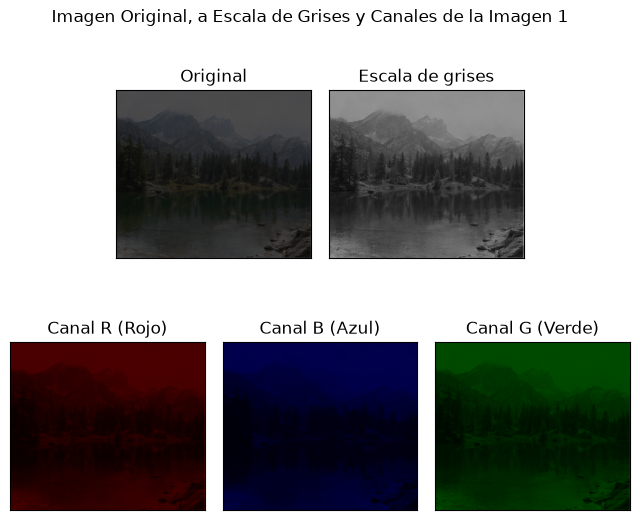

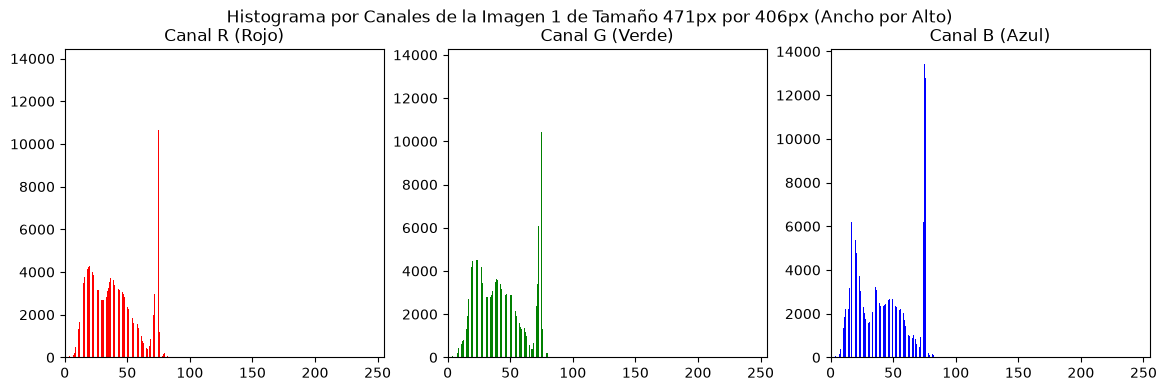

In [9]:
image_1 = images[0]
filename_1 = filenames[0]

describe_1 = visual_describe_image(image_1, filename_1)
channels_1 = channels_histograms(image_1, filename_1)

Como se deriva de los histogramas aplicar una corrección de brillo y ligeramente en el contraste sería suficiente para mejorar la imagen en el sentido que se pueda distinguir de mejor manera los colores. Dicho así, usar un gamma mayor a 1 favorece en un incremento en el brillo, mientras que uno menor a 1 lo reduce, invisibilizando a la imagen.

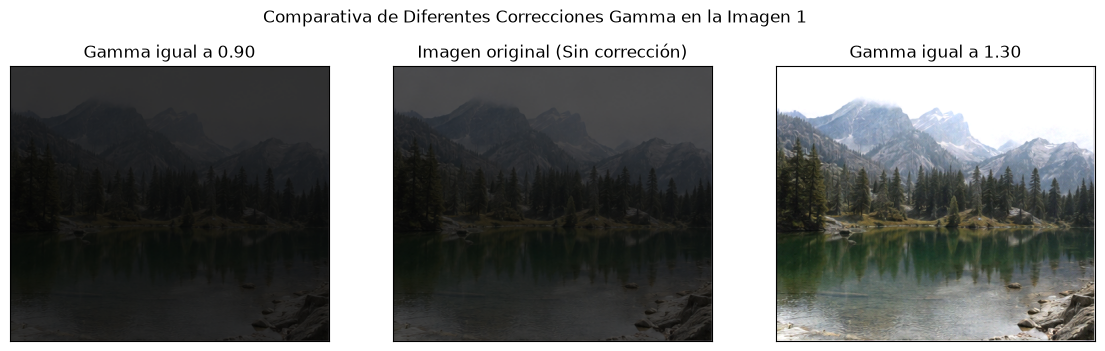

In [10]:
gamma_correction_comparison(
    image_1, 
    filename_1, 
    lower_gamma = 0.9, 
    higher_gamma = 1.3,
);

Con ganancia y sesgo adecuados se puede llegar a resultados parecidos a los obtenidos por corrección gamma.

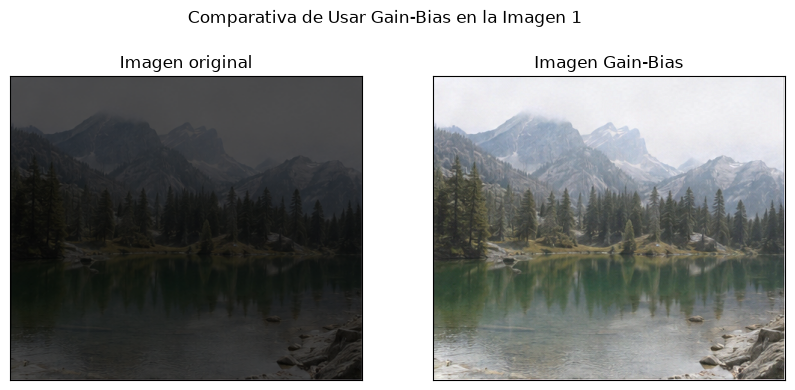

In [11]:
gain_bias_comparison(
    image_1, 
    filename_1, 
    gain = 3, 
    bias = 15,
);

La ecualización por si sola no mejorar la imagen como uno espera, solamente mejora el contraste ligeramente pero el brillo queda igual

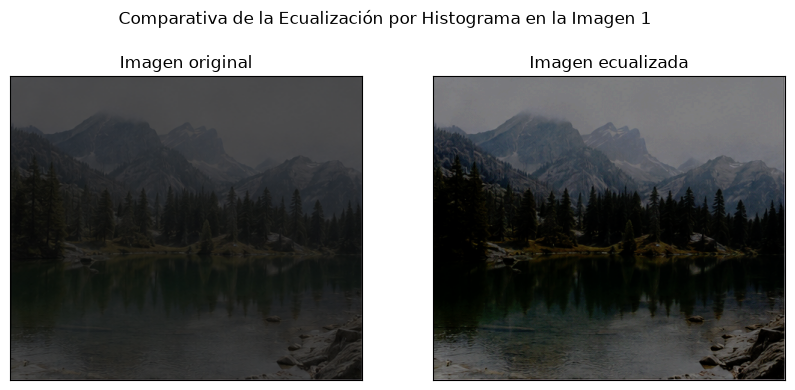

In [12]:
histogram_equalize_comparison(image_1, filename_1);

## 2. Imagen 2: Paisaje de Playa

Esta imagen presenta una sobreexposición, haciendo que sea muy iluminada. Y tal vez no sea necesario cambiar su contraste.

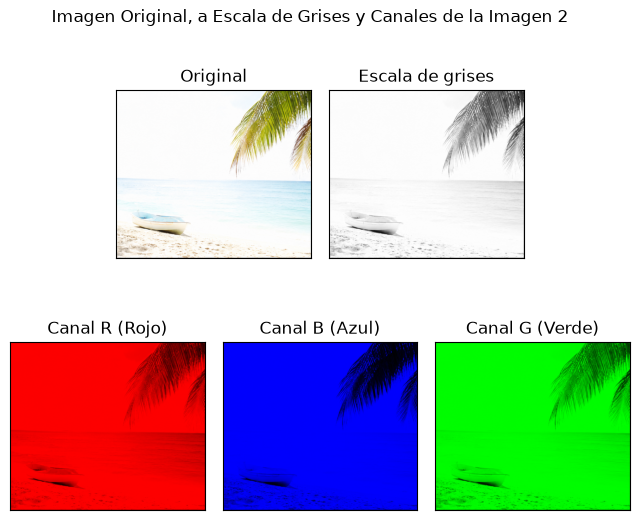

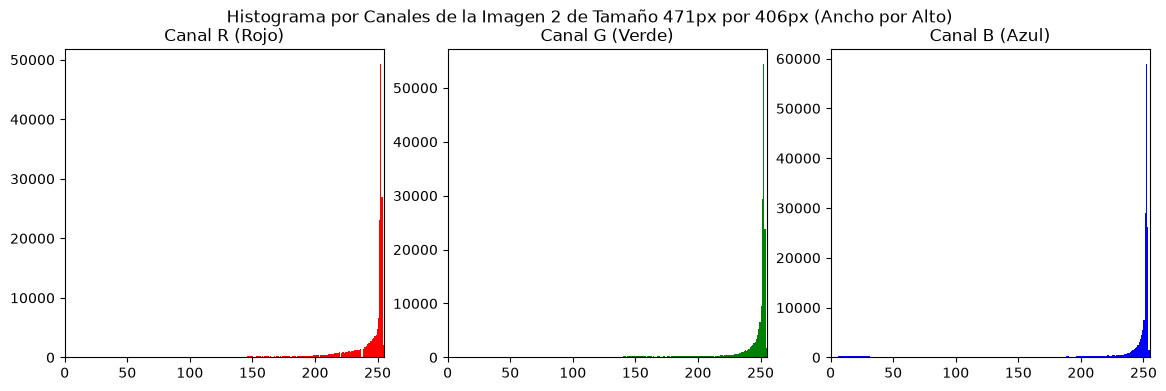

In [13]:
image_2 = images[1]
filename_2 = filenames[1]

describe_2 = visual_describe_image(image_2, filename_2)
channels_2 = channels_histograms(image_2, filename_2)

Por cómo funciona la corrección gamma, hace que tanto el brillo como el contraste disminuyan o incrementen en la misma dirección, esto hace que no se pueda reducir el brillo únicamente. Por ello vemos que un gamma menor a 1 oscurece demasiado a la imagen mientras que un gamma mayor a 1 convierte a la imagen en blanco

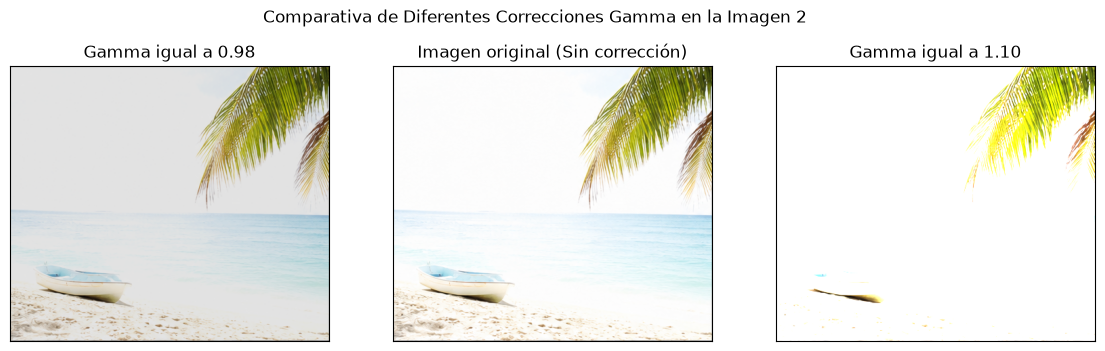

In [14]:
gamma_correction_comparison(
    image_2, 
    filename_2, 
    lower_gamma = 0.98, 
    higher_gamma = 1.1,
);

Al diferencia de la corrección gamma, al usar gain-bias es posible reducir el brillo lo suficiente sin modificar el contraste natural de la imagen. Dicho así, se puede hacer una reducción del brillo más fina.

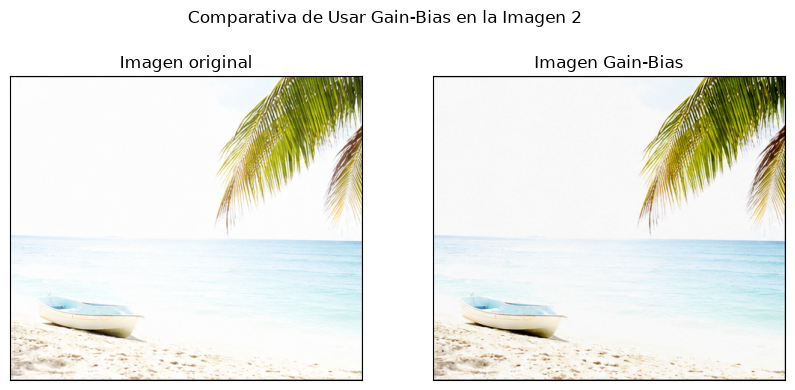

In [15]:
gain_bias_comparison(
    image_2, 
    filename_2, 
    gain = 1.2, 
    bias = -55,
);

La ecualización empeora significativamente la estética de la imagen debido a que redistribuye las intensidades de los colores sin considerar que originalmente los colores tendían a tener valores altos.

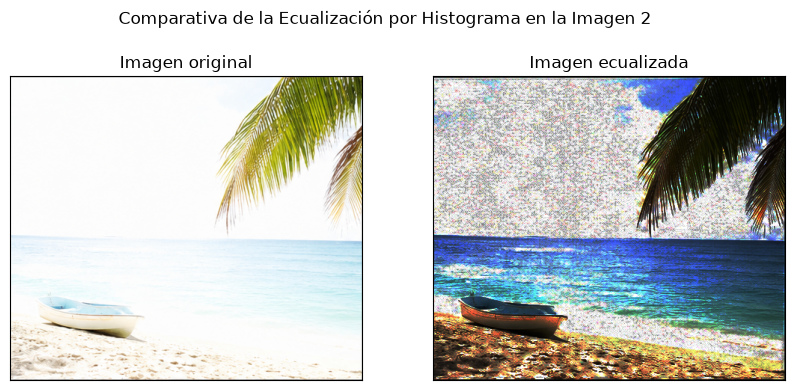

In [16]:
histogram_equalize_comparison(image_2, filename_2);

## 3. Imagen 3: Construcción en Plaza de Noche

Esta imagen presenta una ausencia de iluminación, por lo que primero sería hacerla más brillante a la vez que se mejora su contraste para distinguir los elementos presentes.

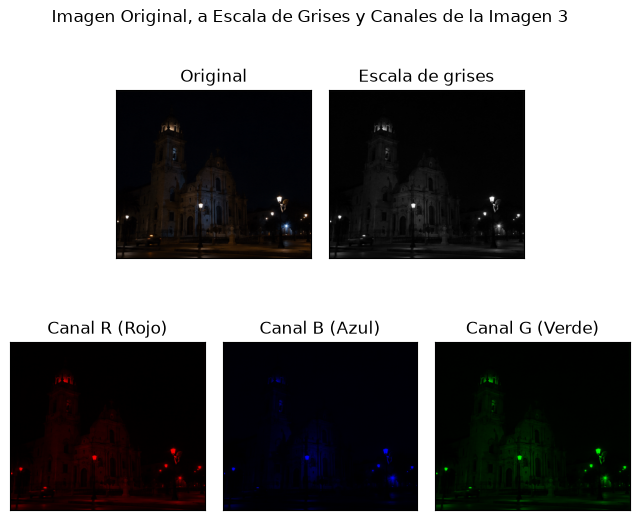

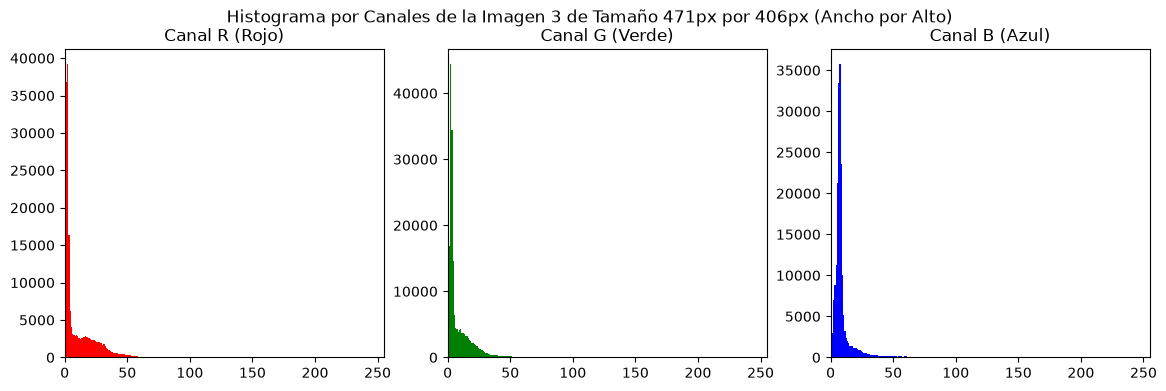

In [17]:
image_3 = images[2]
filename_3 = filenames[2]

describe_3 = visual_describe_image(image_3, filename_3)
channels_3 = channels_histograms(image_3, filename_3)

Como se esperaba, al aplicar la corrección gamma con un gamma mayor a 1 permite mejorar el brillo y contraste de la imagen original, mostrando así los elementos originales sin deteriorar las tonalidades de la mismas.

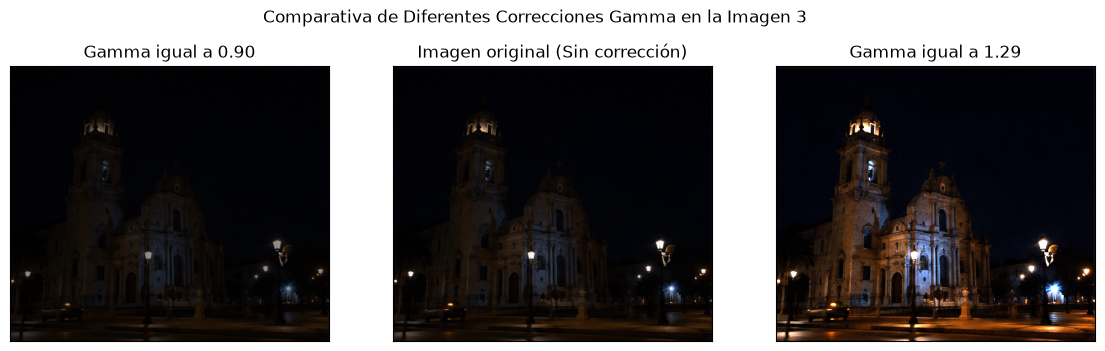

In [18]:
gamma_correction_comparison(
    image_3, 
    filename_3, 
    lower_gamma = 0.9, 
    higher_gamma = 1.29,
);

De igual manera, con gain y bias adecuados es posibles resaltar los colores y elementos presentes en la imagen sin añadir ruido extra o una sobresaturación (como puede pasar con las correcciones gammas)

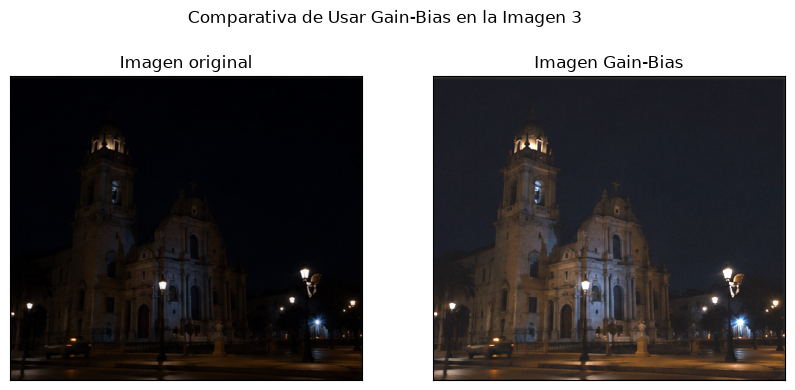

In [19]:
gain_bias_comparison(
    image_3, 
    filename_3, 
    gain = 2, 
    bias = 25,
);

Como pasa en la imagen 2 que todos los colores se concentran en una misma tonalidad, al ecualizarlos las tonalidades se redistribuyen por todo el espectro haciendo que la imagen se degrade y pierda estética.

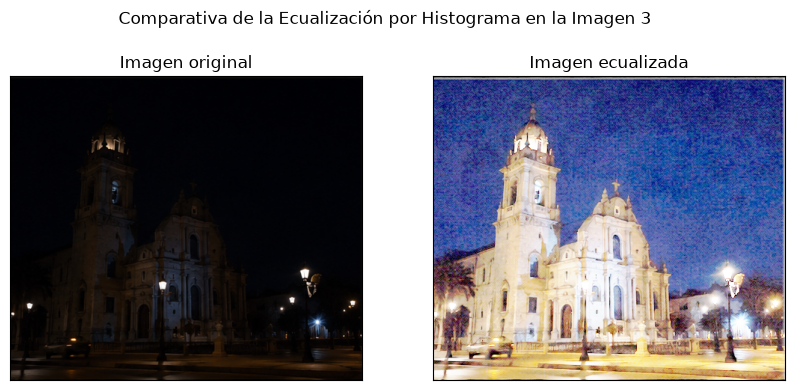

In [20]:
histogram_equalize_comparison(image_3, filename_3);

## 4. Imagen 4: Planta en Maceta

El principal defecto de esta imagen es que tiene un brillo elevado pero cuenta con un buen contraste y se distinguen de buena manera los elementos que la conforman.

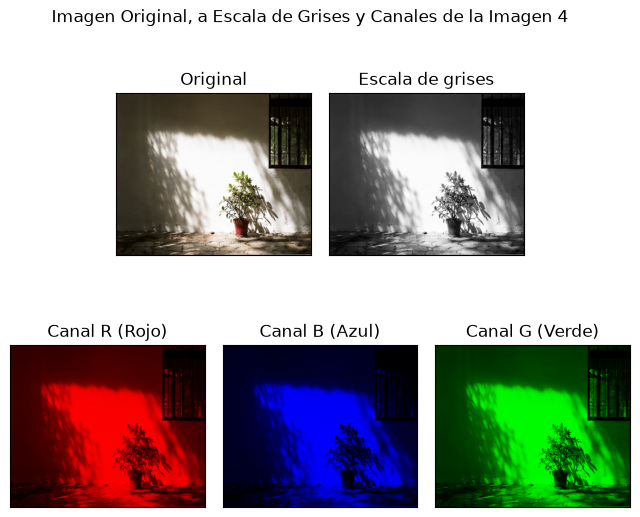

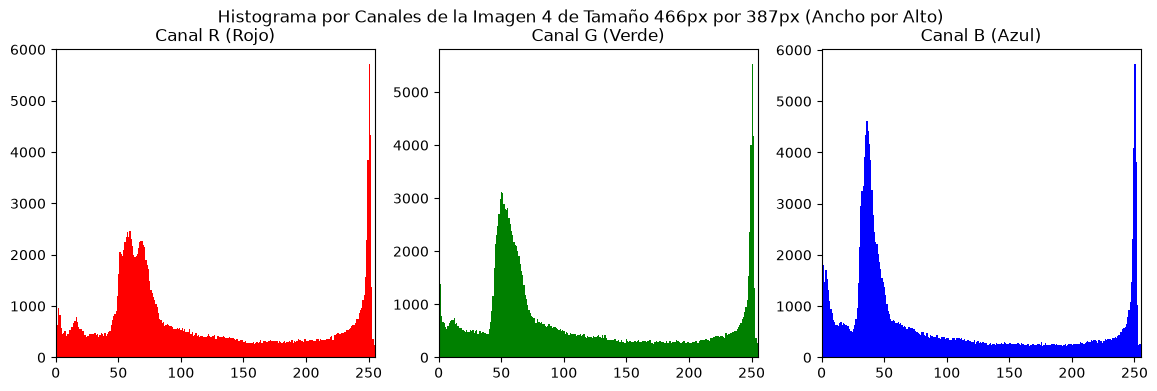

In [21]:
image_4 = images[3]
filename_4 = filenames[3]

describe_4 = visual_describe_image(image_4, filename_4)
channels_4 = channels_histograms(image_4, filename_4)

Por lo mencionado, al aplicar cualquier corrección gamma hará que la imagen se oscurezca (en cada de un gamma menor a 1) o tenga una mayor sobreexposición/iluminación (en el caso contrario). Por ello, esta técnica no es la indicada

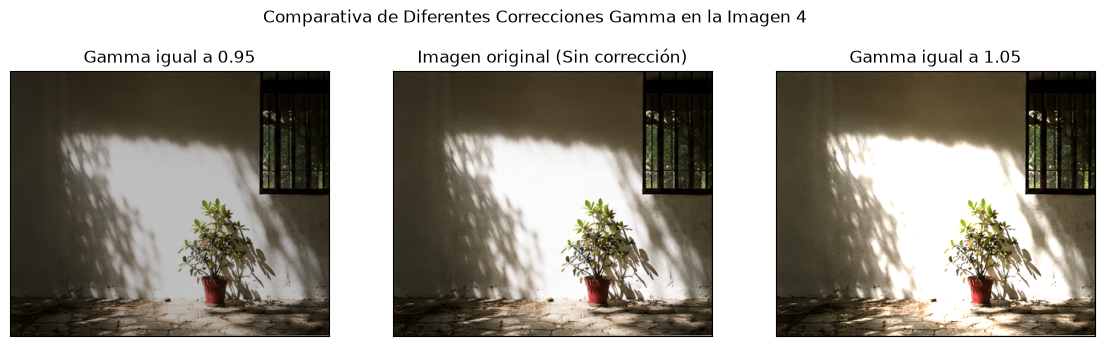

In [22]:
gamma_correction_comparison(
    image_4, 
    filename_4, 
    lower_gamma = 0.95, 
    higher_gamma = 1.05,
);

Con los parámetros adecuados, se logra reducir el brillo de la imagen sin degradar de forma notoria el contraste de los colores. 

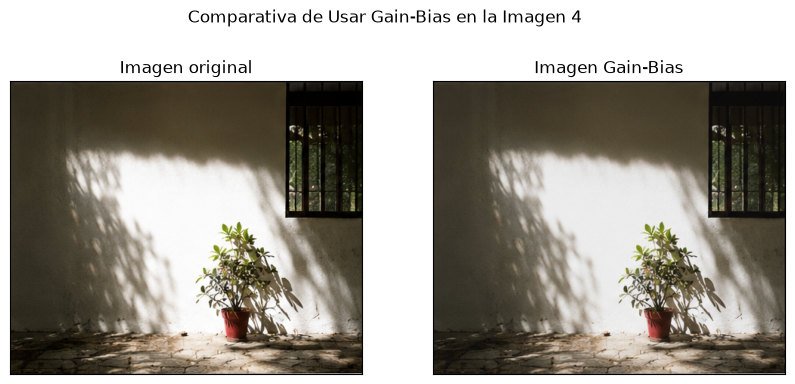

In [23]:
gain_bias_comparison(
    image_4, 
    filename_4, 
    gain = 0.9, 
    bias = 10,
);

De forma general, la ecualización por histograma no "cambia" los colores de la imagen pero si aclarece las zonas oscuras pero se sigue entendiendo los elementos importantes de la imagen.

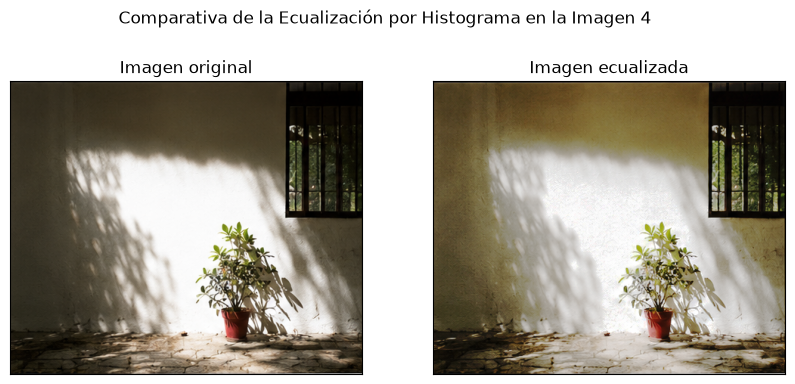

In [24]:
histogram_equalize_comparison(image_4, filename_4);

## 5. Imagen 5: 

En esta imagen podemos rescatar que el canal verde no cuenta con la suficiente saturación, por ello la imagen se ve violeta/morada en vez de tener alguno de los tonos esperados. Por ello, las diferentes técnicas no se aplicarán sobre toda la imagen sino sobre un único canal

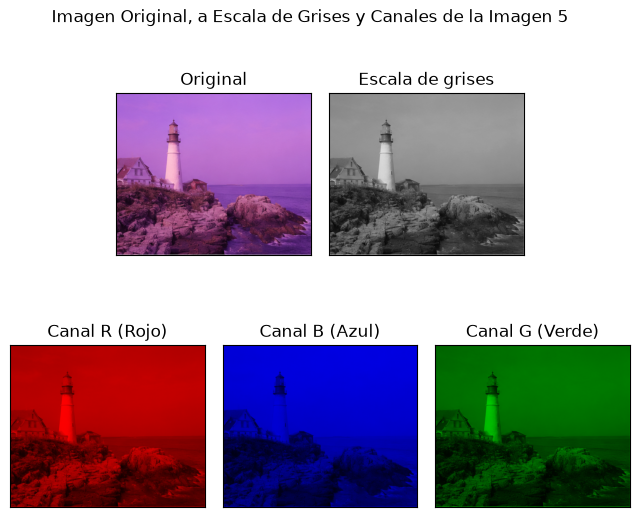

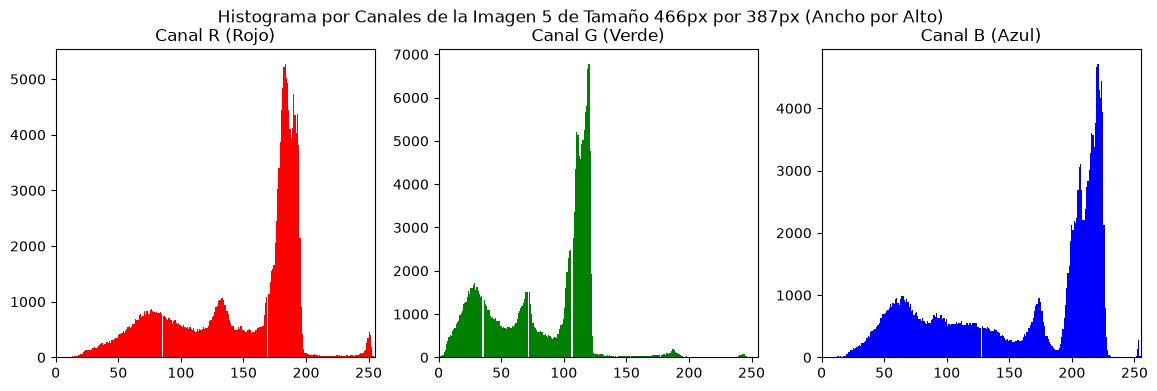

In [25]:
image_5 = images[4]
filename_5 = filenames[4]

describe_5 = visual_describe_image(image_5, filename_5)
channels_5 = channels_histograms(image_5, filename_5)

Si aplica la corrección gamma al canal verde, veremos que al usar un gamma mayor a 1 añade artifacts de colores y, adicionalmente, no resuelve el problema de la baja exposición del verde.

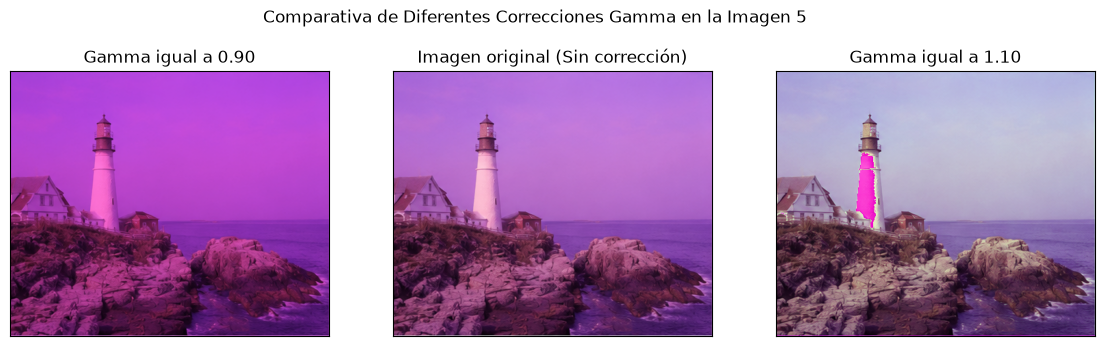

In [26]:
gamma_correction_comparison(
    image_5, 
    filename_5, 
    lower_gamma = 0.9, 
    higher_gamma = 1.1,
    channels = [1]
);

Aplicar la transformación gain-bias sobre el canal verde genera la corrección que estamos buscando, incrementar la saturación del canal verde, logrando así un mejora significativa.

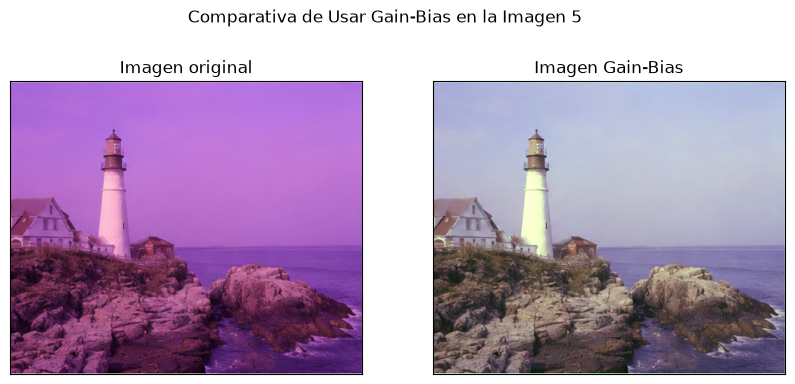

In [27]:
gain_bias_comparison(
    image_5, 
    filename_5, 
    gain = 1.5, 
    bias = 20,
    channels = [1],
);

En general, la ecualización no realiza ningún cambio en la imagen y tampoco la mejora.

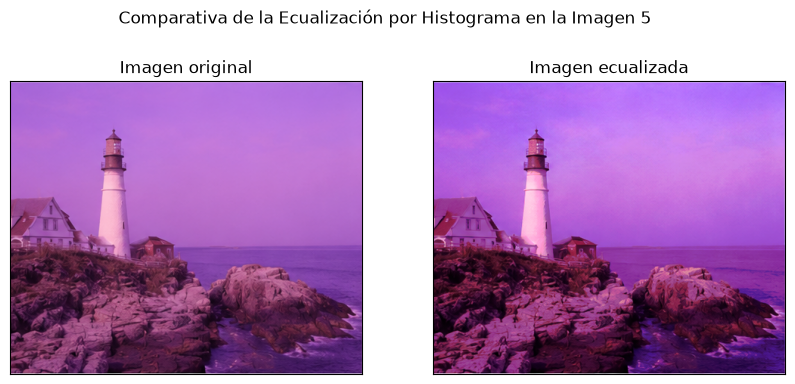

In [28]:
histogram_equalize_comparison(image_5, filename_5);